# Correlation Analysis Per Video: Pose Features vs IRAF SAT (n=10)

In [13]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

FEATURES_DIR = '../data/processed/features/'
OUT_DIR      = '../data/processed/features/pose/per_video/'
os.makedirs(OUT_DIR, exist_ok=True)

KORS_PATH   = '../data/original/Forts_IRAF_SAT_Kors _Gemensamt.xlsx'
RAK_PATH    = '../data/original/Final_IRAF_SAT_Rak_Bedömare sep och gemensamt.xlsx'
KORS_VIDEOS = ['028', '045', '059', '074', '091']
RAK_VIDEOS  = ['030', '047', '061', '076', '093']

## Spearman correlations between pose features and IRAF SAT scores per video
- **n=10** 
- `Kors armar:` videos 028,045,059,074,091.
- `Rak armar:` 030,047,061,076,093.

In [14]:
def parse_iraf_per_video(xl, sheet_name, fp_videos=None):
    raw = xl.parse(sheet_name, header=None)
    col0 = raw.iloc[:, 0].fillna('').astype(str)

    # Support header formats:
    #   KORS: "Försöksperson: SB. Film Nr: 028"
    #   RAK sit-to-stand: "Fp1_Sittande till stående, Video 030"
    #   RAK stand-to-sit: "Fp1_Stående till sittande" (no video; pass fp_videos)
    is_block = col0.str.contains('Film Nr', na=False) | col0.str.contains(', [Vv]ideo ', na=False, regex=True)
    if fp_videos is not None:
        is_block = is_block | col0.str.match(r'Fp\d+_', na=False)
    block_rows = raw.index[is_block].tolist()
    block_rows.append(len(raw))

    def get_video(text):
        if 'Film Nr' in text:
            return text.split('Film Nr:')[1].strip().split()[0].zfill(3)
        elif ', video ' in text.lower():
            return text.lower().split(', video ')[1].strip().split()[0].zfill(3)
        elif fp_videos is not None:
            m = re.match(r'Fp(\d+)_', text)
            if m:
                idx = int(m.group(1)) - 1
                return fp_videos[idx] if idx < len(fp_videos) else None
        return None

    records = []
    phase_weight_records = []
    for i, start in enumerate(block_rows[:-1]):
        video = get_video(col0.iloc[start])
        if video is None:
            continue
        block = raw.iloc[start:block_rows[i+1]]
        bc0 = block.iloc[:, 0].fillna('').astype(str)
        up_idx = bc0[bc0.str.strip() == 'Utgångsposition'].index
        rs_idx = bc0[bc0.str.strip() == 'Rörelsestart'].index
        ru_idx = bc0[bc0.str.strip() == 'Rörelseutförande'].index
        if not (len(up_idx) and len(rs_idx) and len(ru_idx)):
            continue
        up_i, rs_i, ru_i = up_idx[0], rs_idx[0], ru_idx[0]
        end_i = block_rows[i+1]
        for phase, p_i in [('utgångsposition', up_i), ('rörelsestart', rs_i), ('rörelseutförande', ru_i)]:
            phase_weight_records.append({'video': video, 'phase': phase, 'phase_weight': raw.iloc[p_i, 1]})
        for phase, p_start, p_end in [
            ('utgångsposition', up_i+1, rs_i),
            ('rörelsestart',    rs_i+1, ru_i),
            ('rörelseutförande', ru_i+1, end_i)
        ]:
            for _, r in raw.iloc[p_start:p_end].iterrows():
                gem = r[12]
                weight = pd.to_numeric(r[1], errors='coerce')
                if pd.notna(weight) and pd.notna(gem) and str(gem).strip().lower() != 'x':
                    records.append({'video': video, 'phase': phase,
                                    'weight': weight, 'avvikelse': float(gem)})
    return pd.DataFrame(records), pd.DataFrame(phase_weight_records)

kors_xl = pd.ExcelFile(KORS_PATH)
rak_xl  = pd.ExcelFile(RAK_PATH)
kors_df, kors_pw = parse_iraf_per_video(kors_xl, 'Sittande till stående')
rak_df,  rak_pw  = parse_iraf_per_video(rak_xl,  'Sittande till stående')
iraf_raw = pd.concat([kors_df, rak_df], ignore_index=True)
iraf_raw = iraf_raw.assign(w=iraf_raw['avvikelse'] * iraf_raw['weight'])

phase_weights = pd.concat([kors_pw, rak_pw]).groupby('phase')['phase_weight'].mean().to_dict()

iraf_pv = iraf_raw.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv.columns.name = None
iraf_pv.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv.columns[1:]]

total_w = sum(phase_weights.values())
iraf_pv['iraf_total'] = sum(iraf_pv[f'iraf_{p}'] * w for p, w in phase_weights.items()) / total_w

iraf_pv

,video,iraf_rörelsestart,iraf_rörelseutförande,iraf_utgångsposition,iraf_total
0,028,1.666667,0.791667,0.870370,1.149306
1,030,0.000000,0.250000,0.055556,0.083333
2,045,1.333333,1.208333,1.407407,1.329861
3,047,2.000000,0.812500,1.523810,1.524554
4,059,1.000000,0.812500,0.937500,0.929688
5,061,1.000000,0.687500,0.650000,0.790625
6,074,1.666667,1.041667,1.047619,1.278274
7,076,1.000000,0.937500,0.555556,0.817708
8,091,1.666667,1.023810,1.460317,1.428571
9,093,1.000000,0.500000,0.722222,0.770833


In [15]:
def load_features(name):
    df = pd.read_csv(FEATURES_DIR + f'{name}.csv')
    df['video'] = df['video'].astype(str).str.zfill(3)
    return df

feat_up = load_features('utgångsposition')
feat_rs = load_features('rörelsestart')
feat_ru = load_features('rörelseutförande')

merged_up = feat_up.merge(iraf_pv[['video', 'iraf_utgångsposition']].rename(columns={'iraf_utgångsposition': 'iraf_score'}), on='video')
merged_rs = feat_rs.merge(iraf_pv[['video', 'iraf_rörelsestart']].rename(columns={'iraf_rörelsestart': 'iraf_score'}), on='video')
merged_ru = feat_ru.merge(iraf_pv[['video', 'iraf_rörelseutförande']].rename(columns={'iraf_rörelseutförande': 'iraf_score'}), on='video')
print(f'n per phase   up:{len(merged_up)}, rs:{len(merged_rs)}, ru:{len(merged_ru)}')


n per phase   up:10, rs:10, ru:10


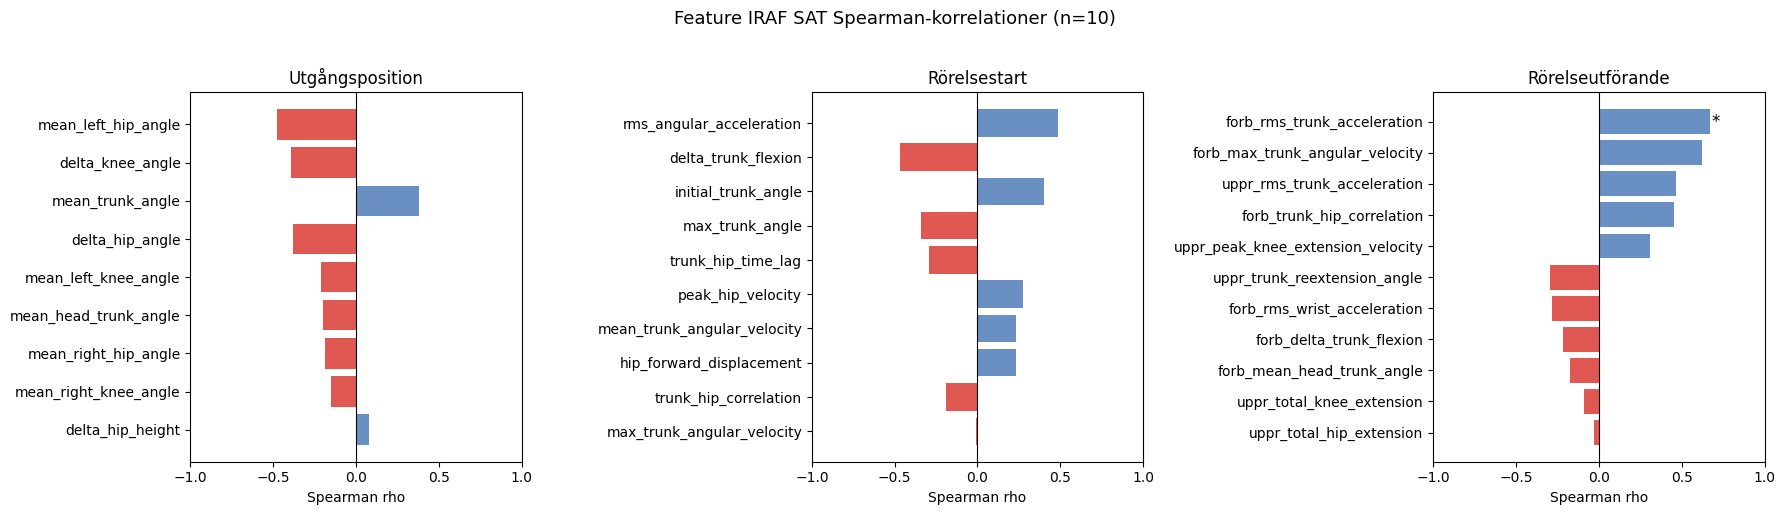

In [16]:
def spearman(df):
    return pd.DataFrame([
        {'feature': c, 'rho': stats.spearmanr(df[c], df['iraf_score'])[0],
                       'p':   stats.spearmanr(df[c], df['iraf_score'])[1]}
        for c in df.columns if c not in ['video', 'iraf_score']
        if df[[c, 'iraf_score']].dropna().__len__() >= 3
    ]).sort_values('rho', key=abs, ascending=False)

corr_up = spearman(merged_up)
corr_rs = spearman(merged_rs)
corr_ru = spearman(merged_ru)

corr_up.to_csv(OUT_DIR + 'corr_utgångsposition.csv', index=False)
corr_rs.to_csv(OUT_DIR + 'corr_rörelsestart.csv', index=False)
corr_ru.to_csv(OUT_DIR + 'corr_rörelseutförande.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, corr, title in zip(axes, [corr_up, corr_rs, corr_ru], ['Utgångsposition', 'Rörelsestart', 'Rörelseutförande']):
    c = corr.set_index('feature')
    ax.barh(c.index, c['rho'], color=['#d73027' if r < 0 else '#4575b4' for r in c['rho']], alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman rho')
    ax.set_title(title)
    ax.invert_yaxis()
    for i, (_, row) in enumerate(c.iterrows()):
        if row['p'] < 0.05:
            ax.text(row['rho'] + (0.03 if row['rho'] >= 0 else -0.03), i, '*', ha='center', va='center', fontsize=12)
plt.suptitle('Feature IRAF SAT Spearman-korrelationer (n=10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR + 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


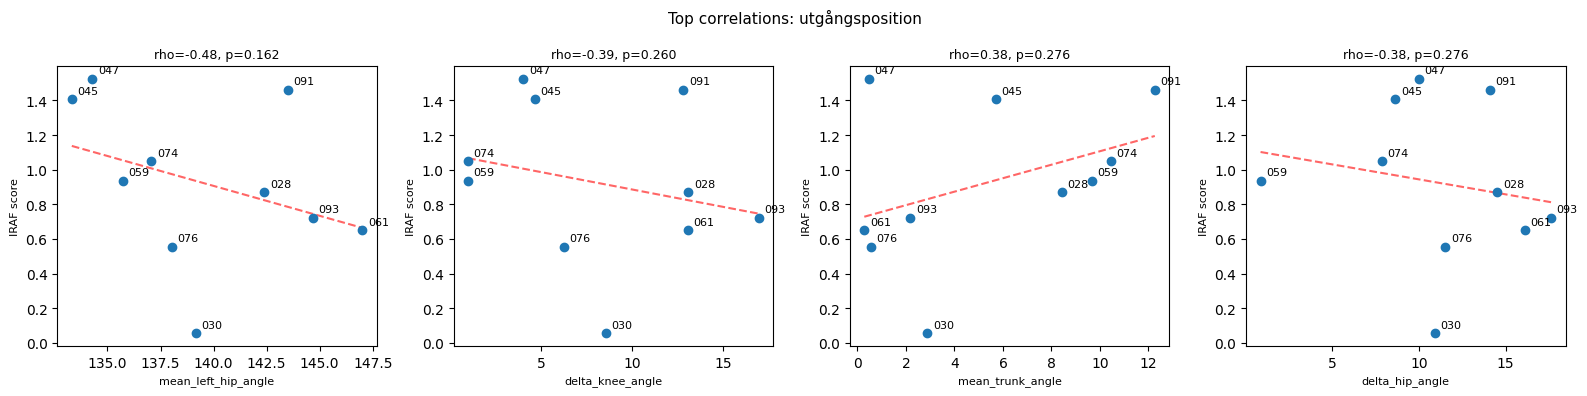

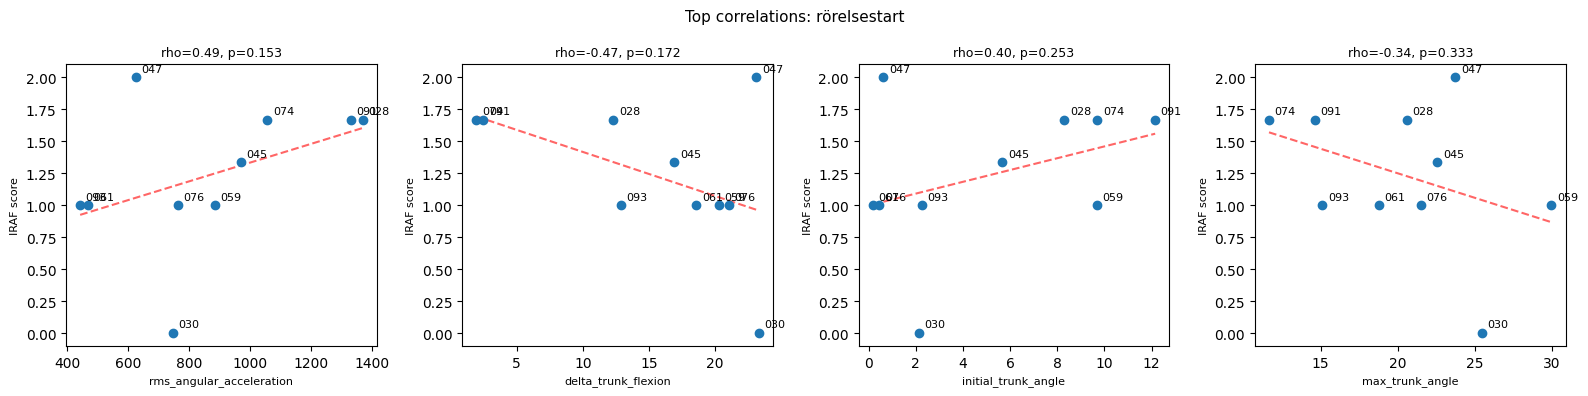

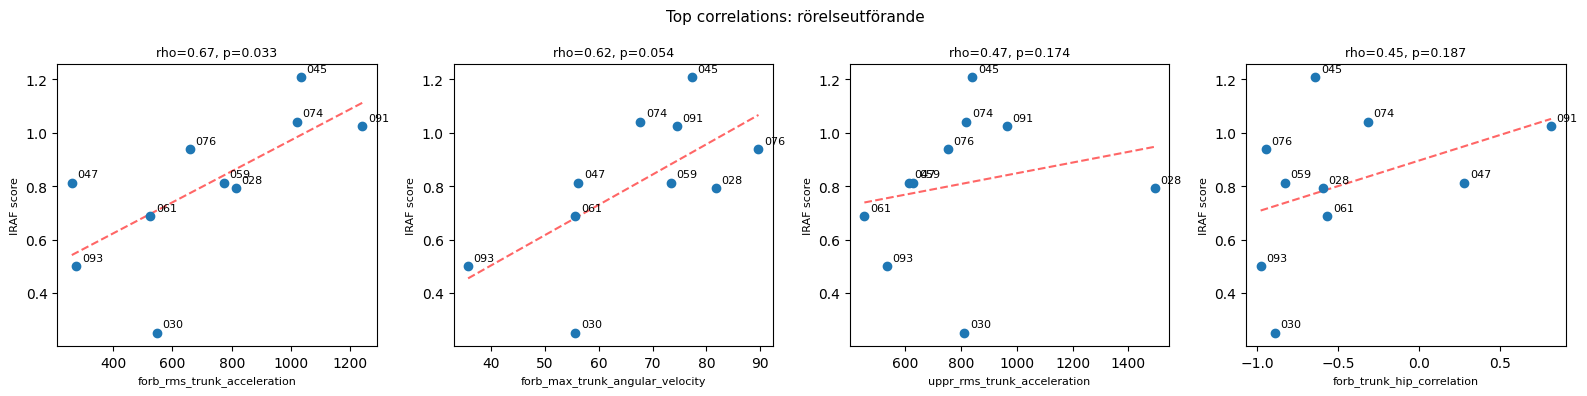

In [17]:
def plot_top_scatters(merged_df, corr_df, phase_name, n_top=4, out_dir=None):
    top = corr_df.head(n_top)
    fig, axes = plt.subplots(1, len(top), figsize=(4*len(top), 4))
    if len(top) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, top.iterrows()):
        fc = row['feature']
        vals = merged_df[['video', fc, 'iraf_score']].dropna()
        ax.scatter(vals[fc], vals['iraf_score'], zorder=3)
        for _, r in vals.iterrows():
            ax.annotate(r['video'], (r[fc], r['iraf_score']),
                        textcoords='offset points', xytext=(4, 4), fontsize=8)
        m, b = np.polyfit(vals[fc], vals['iraf_score'], 1)
        xr = np.linspace(vals[fc].min(), vals[fc].max(), 50)
        ax.plot(xr, m*xr+b, 'r--', alpha=0.6)
        ax.set_xlabel(fc, fontsize=8)
        ax.set_ylabel('IRAF score', fontsize=8)
        ax.set_title(f'rho={row["rho"]:.2f}, p={row["p"]:.3f}', fontsize=9)
    if out_dir is None:
        out_dir = OUT_DIR
    fig.suptitle(f'Top correlations: {phase_name}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{out_dir}scatter_{phase_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_top_scatters(merged_up, corr_up, 'utgångsposition')
plot_top_scatters(merged_rs, corr_rs, 'rörelsestart')
plot_top_scatters(merged_ru, corr_ru, 'rörelseutförande')


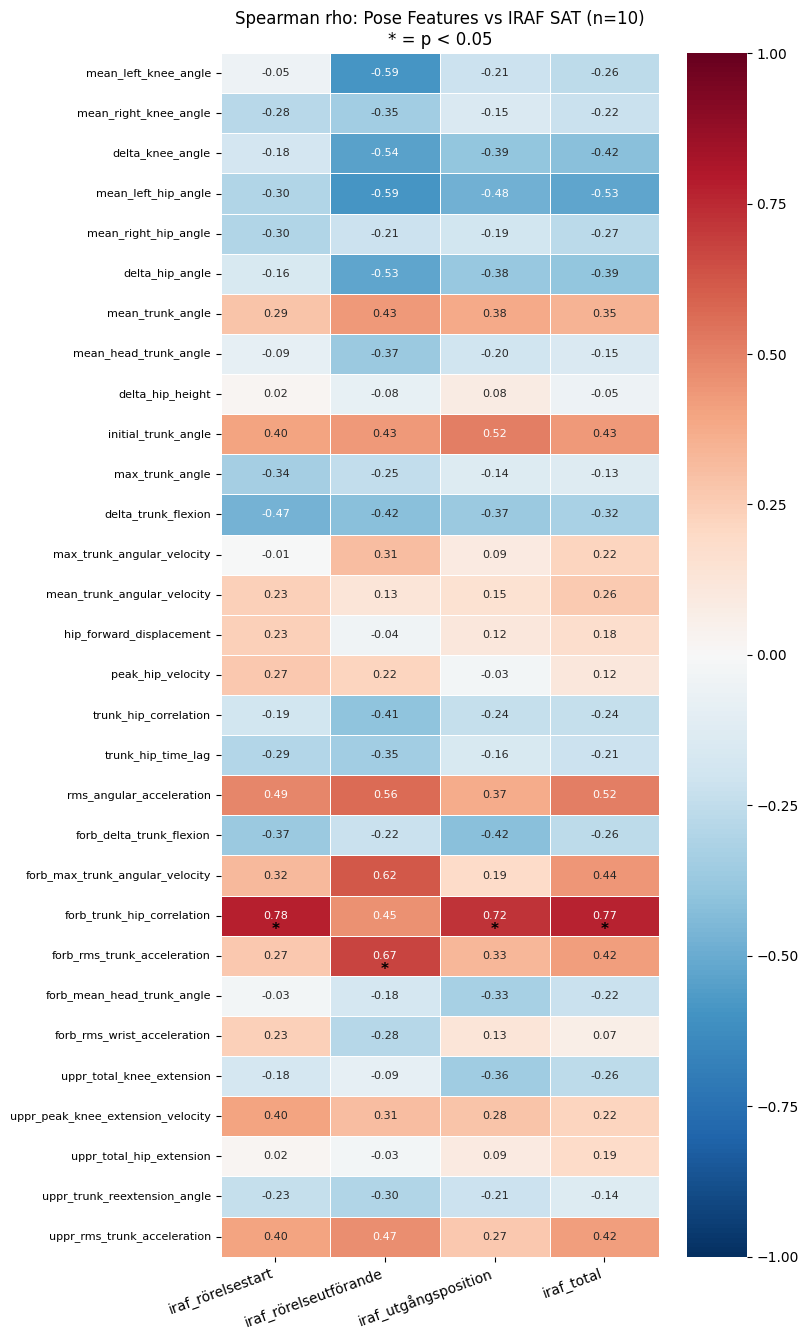

In [18]:
all_feats = feat_up.merge(feat_rs, on='video', how='outer').merge(feat_ru, on='video', how='outer')
merged_all = all_feats.merge(iraf_pv, on='video')

feat_cols = [c for c in all_feats.columns if c != 'video']
iraf_cols = [c for c in iraf_pv.columns if c != 'video']

rho_mat = pd.DataFrame(index=feat_cols, columns=iraf_cols, dtype=float)
p_mat   = pd.DataFrame(index=feat_cols, columns=iraf_cols, dtype=float)
for fc in feat_cols:
    for ic in iraf_cols:
        vals = merged_all[[fc, ic]].dropna()
        if len(vals) >= 3:
            rho_mat.loc[fc, ic], p_mat.loc[fc, ic] = stats.spearmanr(vals[fc], vals[ic])

fig, ax = plt.subplots(figsize=(8, max(8, len(feat_cols) * 0.45)))
sns.heatmap(rho_mat.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, mask=rho_mat.isna(), annot_kws={'size': 8})
for i, fc in enumerate(feat_cols):
    for j, ic in enumerate(iraf_cols):
        if pd.notna(p_mat.loc[fc, ic]) and p_mat.loc[fc, ic] < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Spearman rho: Pose Features vs IRAF SAT (n=10)\n* = p < 0.05', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR + 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
corr_results = pd.DataFrame([
    {'feature': fc, 'iraf_score': ic, 'spearman_rho': rho_mat.loc[fc, ic], 'p_value': p_mat.loc[fc, ic]}
    for fc in feat_cols for ic in iraf_cols
    if pd.notna(rho_mat.loc[fc, ic])
]).sort_values('spearman_rho', key=abs, ascending=False)

corr_results.to_csv(OUT_DIR + 'correlation_results.csv', index=False)
print(f'{len(corr_results)} correlations saved')
corr_results.head(10)


120 correlations saved


,feature,iraf_score,spearman_rho,p_value
84,forb_trunk_hip_correlation,iraf_rörelsestart,0.779246,0.007883
87,forb_trunk_hip_correlation,iraf_total,0.769697,0.009222
86,forb_trunk_hip_correlation,iraf_utgångsposition,0.721212,0.018573
89,forb_rms_trunk_acceleration,iraf_rörelseutförande,0.672727,0.033041
81,forb_max_trunk_angular_velocity,iraf_rörelseutförande,0.624242,0.053718
1,mean_left_knee_angle,iraf_rörelseutförande,-0.587879,0.073878
13,mean_left_hip_angle,iraf_rörelseutförande,-0.587879,0.073878
73,rms_angular_acceleration,iraf_rörelseutförande,0.563636,0.089724
9,delta_knee_angle,iraf_rörelseutförande,-0.539394,0.107593
15,mean_left_hip_angle,iraf_total,-0.527273,0.117308


## Stående till sittande (Stand-to-Sit)

In [20]:
DOWN_FEATURES_DIR = '../data/processed/features_down/'
DOWN_OUT_DIR_POSE = '../data/processed/features_down/pose/per_video/'
os.makedirs(DOWN_OUT_DIR_POSE, exist_ok=True)
RAK_DOWN_FP_VIDEOS = ['030', '047', '061', '076', '093']

kors_df_d, kors_pw_d = parse_iraf_per_video(kors_xl, 'Stående till sittande')
rak_df_d,  rak_pw_d  = parse_iraf_per_video(rak_xl,  'Stående till sittande', fp_videos=RAK_DOWN_FP_VIDEOS)
iraf_raw_d = pd.concat([kors_df_d, rak_df_d], ignore_index=True)
iraf_raw_d = iraf_raw_d.assign(w=iraf_raw_d['avvikelse'] * iraf_raw_d['weight'])

phase_weights_d = pd.concat([kors_pw_d, rak_pw_d]).groupby('phase')['phase_weight'].mean().to_dict()

iraf_pv_d = iraf_raw_d.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv_d.columns.name = None
iraf_pv_d.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv_d.columns[1:]]

total_w_d = sum(phase_weights_d.values())
iraf_pv_d['iraf_total'] = sum(iraf_pv_d[f'iraf_{p}'] * w for p, w in phase_weights_d.items()) / total_w_d

iraf_pv_d


,video,iraf_rörelsestart,iraf_rörelseutförande,iraf_utgångsposition,iraf_total
0,028,0.000000,0.545455,0.428571,0.339518
1,030,0.000000,0.000000,0.000000,0.000000
2,045,0.333333,0.833333,1.125000,0.815476
3,047,1.000000,0.555556,0.600000,0.701587
4,059,0.000000,0.564103,0.666667,0.446886
5,061,0.000000,0.461538,0.733333,0.446154
6,074,0.666667,0.692308,0.444444,0.578755
7,076,2.000000,0.461538,1.133333,1.189011
8,091,0.333333,0.641026,0.555556,0.516484
9,093,0.000000,0.833333,1.000000,0.666667


In [21]:
def load_features_down(name):
    df = pd.read_csv(DOWN_FEATURES_DIR + f'{name}.csv')
    df['video'] = df['video'].astype(str).str.zfill(3)
    return df

feat_up_d = load_features_down('down_utgångsposition')
feat_rs_d = load_features_down('down_rörelsestart')
feat_ru_d = load_features_down('down_rörelseutförande')

merged_up_d = feat_up_d.merge(iraf_pv_d[['video', 'iraf_utgångsposition']].rename(columns={'iraf_utgångsposition': 'iraf_score'}), on='video')
merged_rs_d = feat_rs_d.merge(iraf_pv_d[['video', 'iraf_rörelsestart']].rename(columns={'iraf_rörelsestart': 'iraf_score'}), on='video')
merged_ru_d = feat_ru_d.merge(iraf_pv_d[['video', 'iraf_rörelseutförande']].rename(columns={'iraf_rörelseutförande': 'iraf_score'}), on='video')
print(f'n per phase   up:{len(merged_up_d)}, rs:{len(merged_rs_d)}, ru:{len(merged_ru_d)}')


n per phase   up:10, rs:10, ru:10


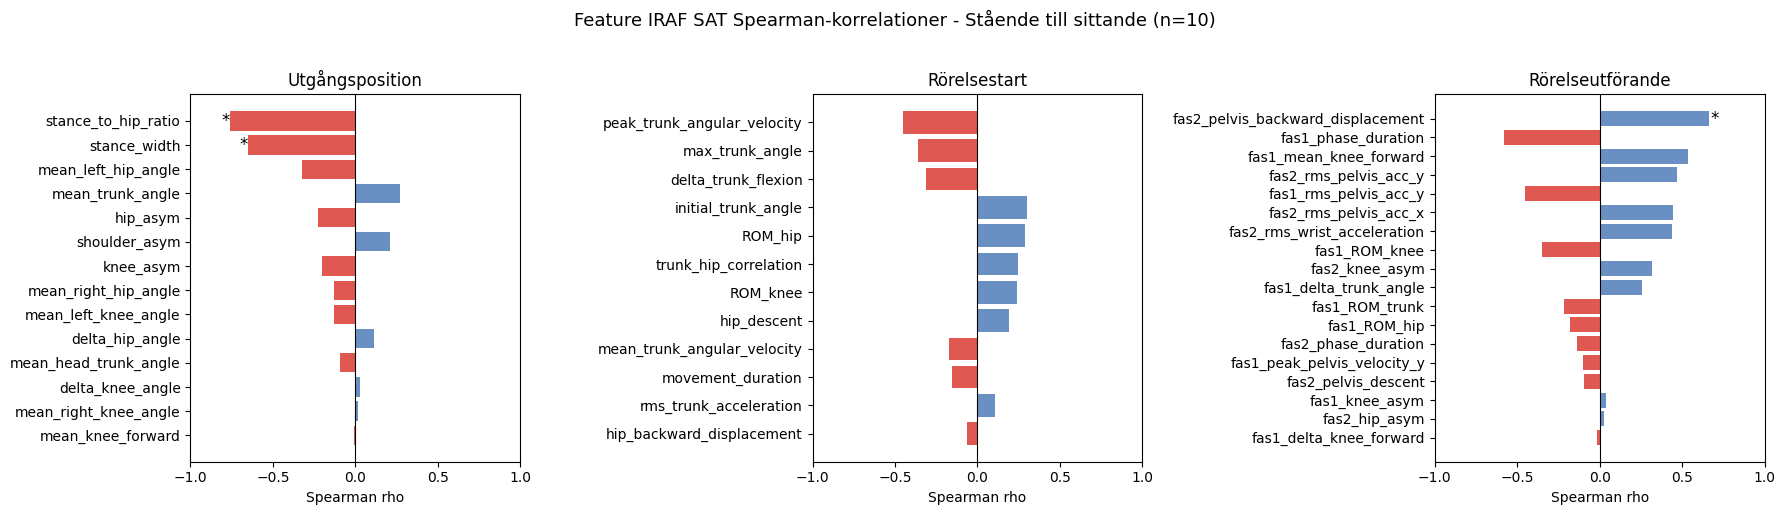

In [22]:
corr_up_d = spearman(merged_up_d)
corr_rs_d = spearman(merged_rs_d)
corr_ru_d = spearman(merged_ru_d)

corr_up_d.to_csv(DOWN_OUT_DIR_POSE + 'corr_utgångsposition.csv', index=False)
corr_rs_d.to_csv(DOWN_OUT_DIR_POSE + 'corr_rörelsestart.csv', index=False)
corr_ru_d.to_csv(DOWN_OUT_DIR_POSE + 'corr_rörelseutförande.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, corr, title in zip(axes, [corr_up_d, corr_rs_d, corr_ru_d], ['Utgångsposition', 'Rörelsestart', 'Rörelseutförande']):
    c = corr.set_index('feature')
    ax.barh(c.index, c['rho'], color=['#d73027' if r < 0 else '#4575b4' for r in c['rho']], alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman rho')
    ax.set_title(title)
    ax.invert_yaxis()
    for i, (_, row) in enumerate(c.iterrows()):
        if row['p'] < 0.05:
            ax.text(row['rho'] + (0.03 if row['rho'] >= 0 else -0.03), i, '*', ha='center', va='center', fontsize=12)
plt.suptitle('Feature IRAF SAT Spearman-korrelationer - Stående till sittande (n=10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOWN_OUT_DIR_POSE + 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


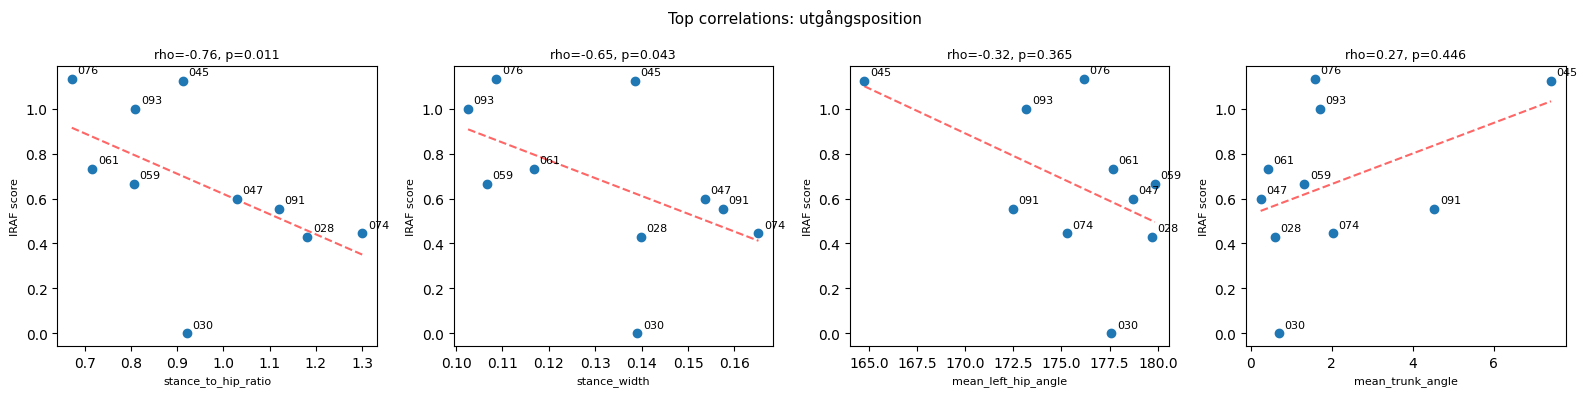

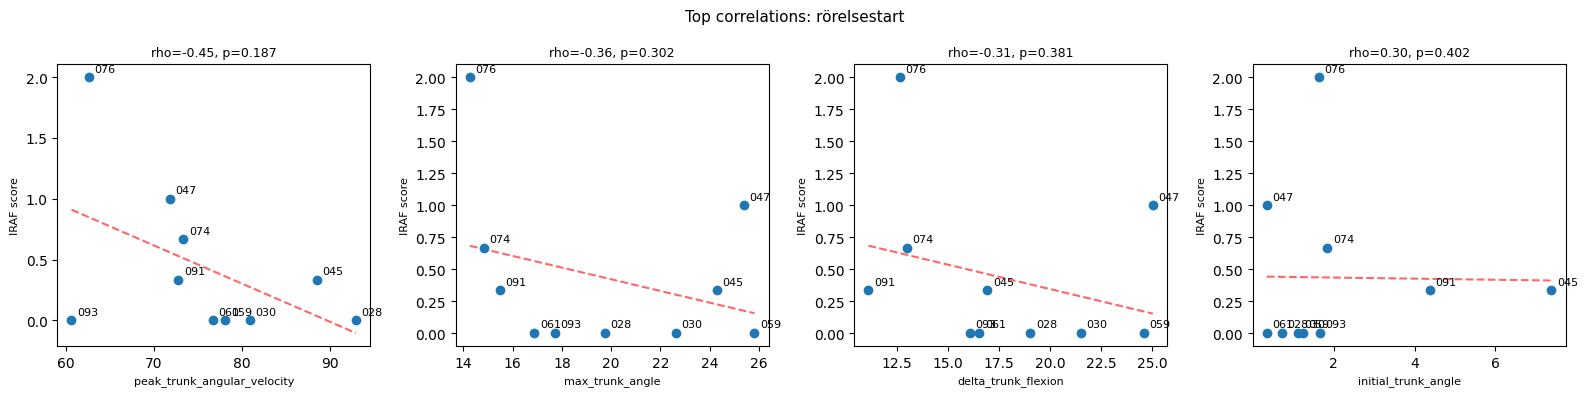

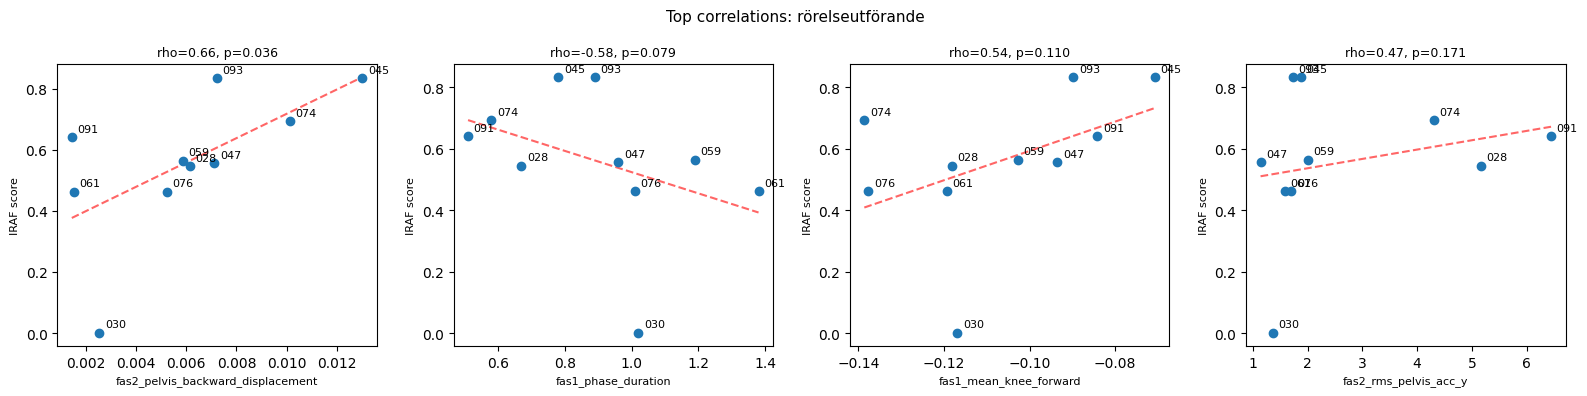

In [23]:
plot_top_scatters(merged_up_d, corr_up_d, 'utgångsposition', out_dir=DOWN_OUT_DIR_POSE)
plot_top_scatters(merged_rs_d, corr_rs_d, 'rörelsestart',    out_dir=DOWN_OUT_DIR_POSE)
plot_top_scatters(merged_ru_d, corr_ru_d, 'rörelseutförande', out_dir=DOWN_OUT_DIR_POSE)


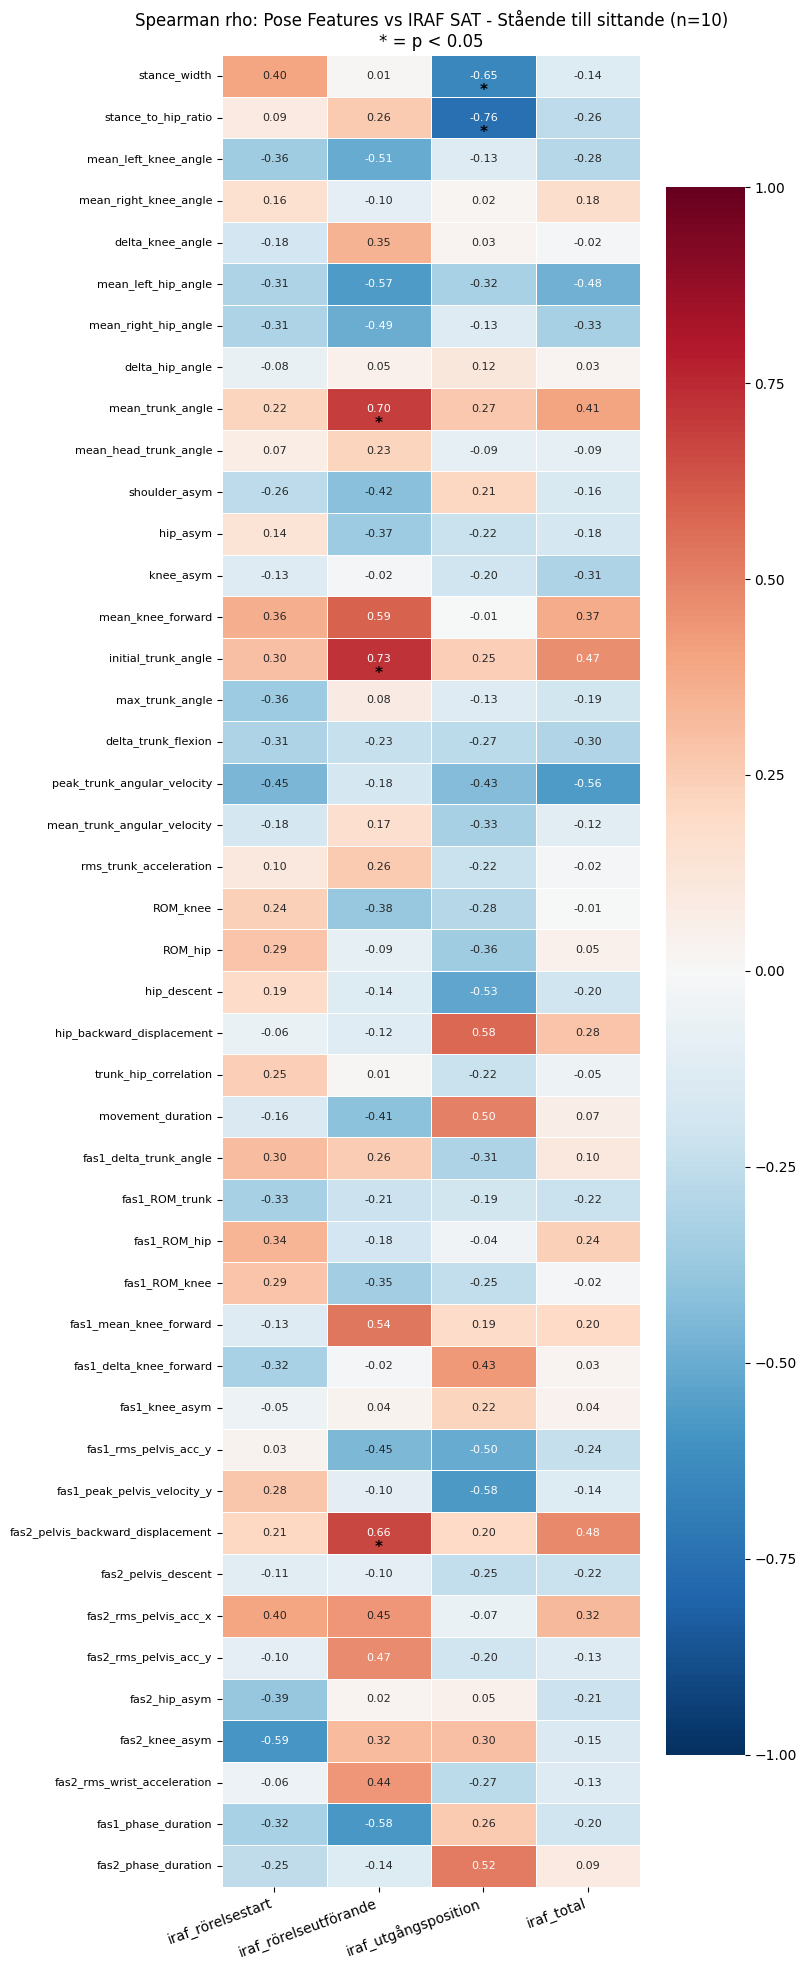

In [24]:
all_feats_d = feat_up_d.merge(feat_rs_d, on='video', how='outer').merge(feat_ru_d, on='video', how='outer')
merged_all_d = all_feats_d.merge(iraf_pv_d, on='video')

feat_cols_d = [c for c in all_feats_d.columns if c != 'video']
iraf_cols_d = [c for c in iraf_pv_d.columns if c != 'video']

rho_mat_d = pd.DataFrame(index=feat_cols_d, columns=iraf_cols_d, dtype=float)
p_mat_d   = pd.DataFrame(index=feat_cols_d, columns=iraf_cols_d, dtype=float)
for fc in feat_cols_d:
    for ic in iraf_cols_d:
        vals = merged_all_d[[fc, ic]].dropna()
        if len(vals) >= 3:
            rho_mat_d.loc[fc, ic], p_mat_d.loc[fc, ic] = stats.spearmanr(vals[fc], vals[ic])

fig, ax = plt.subplots(figsize=(8, max(8, len(feat_cols_d) * 0.45)))
sns.heatmap(rho_mat_d.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, mask=rho_mat_d.isna(), annot_kws={'size': 8})
for i, fc in enumerate(feat_cols_d):
    for j, ic in enumerate(iraf_cols_d):
        if pd.notna(p_mat_d.loc[fc, ic]) and p_mat_d.loc[fc, ic] < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Spearman rho: Pose Features vs IRAF SAT - Stående till sittande (n=10)\n* = p < 0.05', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(DOWN_OUT_DIR_POSE + 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
corr_results_d = pd.DataFrame([
    {'feature': fc, 'iraf_score': ic, 'spearman_rho': rho_mat_d.loc[fc, ic], 'p_value': p_mat_d.loc[fc, ic]}
    for fc in feat_cols_d for ic in iraf_cols_d
    if pd.notna(rho_mat_d.loc[fc, ic])
]).sort_values('spearman_rho', key=abs, ascending=False)

corr_results_d.to_csv(DOWN_OUT_DIR_POSE + 'correlation_results.csv', index=False)
print(f'{len(corr_results_d)} correlations saved')
corr_results_d.head(10)


176 correlations saved


,feature,iraf_score,spearman_rho,p_value
6,stance_to_hip_ratio,iraf_utgångsposition,-0.757576,0.011143
57,initial_trunk_angle,iraf_rörelseutförande,0.725623,0.017528
33,mean_trunk_angle,iraf_rörelseutförande,0.695135,0.025647
141,fas2_pelvis_backward_displacement,iraf_rörelseutförande,0.664647,0.036028
2,stance_width,iraf_utgångsposition,-0.648485,0.042540
53,mean_knee_forward,iraf_rörelseutförande,0.591474,0.071695
160,fas2_knee_asym,iraf_rörelsestart,-0.590362,0.072366
169,fas1_phase_duration,iraf_rörelseutförande,-0.579279,0.079272
138,fas1_peak_pelvis_velocity_y,iraf_utgångsposition,-0.575758,0.081553
94,hip_backward_displacement,iraf_utgångsposition,0.575758,0.081553
